# Lightweight Alignment of Vision-Language Representations via Embedding Denoising

## Complete Research Pipeline

This notebook implements:
1. Dataset loading and preparation
2. Baseline: Contrastive fine-tuning
3. Diffusion alignment module (1D U-Net + training)
4. Evaluation and comparison
5. Hyperparameter ablation studies


## Step 1: Setup and Dataset Loading


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
from datasets import load_dataset

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


2026-01-24 19:40:21.561749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769283621.791587      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769283621.856687      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769283622.375887      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769283622.375929      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769283622.375932      55 computation_placer.cc:177] computation placer alr

Using device: cuda


In [2]:
# Load dataset
dataset = load_dataset("SKyu/my-image-captioning-dataset")

# Consistent dataset splits for all experiments
train_dataset = dataset["train"].select(range(2000, 3000))  # 1000 samples
val_dataset = dataset["train"].select(range(1, 1000))      # 999 samples
test_dataset = dataset["train"].select(range(1000, 2000))  # 1000 samples

print(f"Train: {len(train_dataset)} samples")
print(f"Val: {len(val_dataset)} samples")
print(f"Test: {len(test_dataset)} samples")


README.md:   0%|          | 0.00/463 [00:00<?, ?B/s]

data/train-00000-of-00001-3e9e72b53b09ab(…):   0%|          | 0.00/481M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Train: 1000 samples
Val: 999 samples
Test: 1000 samples


In [3]:
# Data collation function
def collate_fn(batch):
    images = [item["image"] for item in batch]
    captions = [item["prompt"] for item in batch]
    return images, captions

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


In [4]:
# Load frozen CLIP model (used by both methods)
processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

# Freeze CLIP for embedding extraction
clip_model.eval()
for param in clip_model.parameters():
    param.requires_grad = False

# Helper function to get CLIP embeddings
@torch.no_grad()
def get_clip_embeddings(images, captions):
    """Extract normalized CLIP embeddings"""
    inputs = processor(
        text=captions, images=images, return_tensors="pt",
        padding=True, truncation=True, max_length=77
    ).to(device)

    img_embeds = F.normalize(
        clip_model.get_image_features(inputs["pixel_values"]), dim=-1
    )
    text_inputs = {k: v for k, v in inputs.items()
                   if k in ["input_ids", "attention_mask"]}
    txt_embeds = F.normalize(
        clip_model.get_text_features(**text_inputs), dim=-1
    )
    return img_embeds, txt_embeds


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

## Step 2: Baseline - Contrastive Fine-Tuning


In [5]:
# Create a copy of CLIP for fine-tuning (baseline method)
baseline_model = AutoModelForZeroShotImageClassification.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)
baseline_model.train()

baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-6)

print("Training baseline (contrastive fine-tuning)...")
num_epochs_baseline = 10
baseline_train_losses = []

for epoch in range(num_epochs_baseline):
    baseline_model.train()
    epoch_loss = 0

    for images, captions in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs_baseline}"):
        inputs = processor(
            text=captions, images=images, return_tensors="pt",
            padding=True, truncation=True, max_length=77
        ).to(device)

        outputs = baseline_model(**inputs)
        logits_per_image = outputs.logits_per_image
        logits_per_text = outputs.logits_per_text

        batch_size = logits_per_image.size(0)
        labels = torch.arange(batch_size, device=device)

        # Contrastive loss (cross-entropy on similarity matrix)
        loss_i = F.cross_entropy(logits_per_image, labels)
        loss_t = F.cross_entropy(logits_per_text, labels)
        loss = (loss_i + loss_t) / 2

        baseline_optimizer.zero_grad()
        loss.backward()
        baseline_optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    baseline_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

print("✅ Baseline training complete!")


Training baseline (contrastive fine-tuning)...



Epoch 1/10: 100%|██████████| 32/32 [00:34<00:00,  1.08s/it]


Epoch 1, Avg Loss: 0.7577


Epoch 2/10: 100%|██████████| 32/32 [00:32<00:00,  1.02s/it]


Epoch 2, Avg Loss: 0.3114


...

Epoch 8, Avg Loss: 0.0585


Epoch 9/10: 100%|██████████| 32/32 [00:33<00:00,  1.04s/it]


Epoch 9, Avg Loss: 0.0504


Epoch 10/10: 100%|██████████| 32/32 [00:33<00:00,  1.04s/it]

Epoch 10, Avg Loss: 0.0420
✅ Baseline training complete!


## Step 3: Diffusion Alignment Module - 1D U-Net Architecture


In [6]:
class UNet1DResidualDenoiser(nn.Module):
    """
    1D U-Net Residual Denoiser for CLIP embeddings
    Cross-modal conditioning: uses text to denoise images (and vice versa)
    """
    def __init__(self, embedding_dim=512, hidden_dim=1024):
        super().__init__()

        # Encoder (takes residual + conditioning)
        self.enc1 = nn.Linear(embedding_dim * 2, hidden_dim)  # *2 for cross-modal conditioning
        self.enc2 = nn.Linear(hidden_dim, hidden_dim)

        # Decoder
        self.dec1 = nn.Linear(hidden_dim, hidden_dim)
        self.dec2 = nn.Linear(hidden_dim, embedding_dim)

        self.act = nn.ReLU()

    def forward(self, x_noisy, x_clean=None, cond=None):
        """
        x_noisy: noisy embedding to denoise
        x_clean: clean embedding (for computing residual during training)
        cond: conditional embedding (cross-modal, e.g., text for image denoising)
        """
        # Compute residual noise
        if x_clean is not None:
            residual = x_noisy - x_clean
        else:
            residual = x_noisy

        # Cross-modal conditioning: concatenate residual with condition
        if cond is not None:
            x = torch.cat([residual, cond], dim=-1)
        else:
            x = residual

        # Encoder
        e1 = self.act(self.enc1(x))
        e2 = self.act(self.enc2(e1))

        # Decoder with skip connection
        d1 = self.act(self.dec1(e2) + e1)
        d2 = self.dec2(d1)

        # Residual subtraction: remove predicted noise
        x_denoised = x_noisy - d2
        return x_denoised


In [7]:
# Noise schedule functions
def add_noise_linear(embeddings, t, max_std=0.3):
    """Linear noise schedule: noise_std = t * max_std"""
    noise_std = t * max_std
    return embeddings + torch.randn_like(embeddings) * noise_std

def add_noise_cosine(embeddings, t, max_std=0.3):
    """Cosine noise schedule: more noise at later timesteps"""
    noise_std = max_std * (1 - np.cos(t * np.pi / 2))
    return embeddings + torch.randn_like(embeddings) * noise_std

# Contrastive loss function (for diffusion training)
def contrastive_loss(img_embeds, txt_embeds, temperature=0.07):
    """Contrastive loss using cross-entropy on similarity matrix"""
    img_embeds = F.normalize(img_embeds, dim=-1)
    txt_embeds = F.normalize(txt_embeds, dim=-1)

    logits = img_embeds @ txt_embeds.T / temperature
    labels = torch.arange(img_embeds.size(0), device=img_embeds.device)

    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)

    return (loss_i2t + loss_t2i) / 2


## Step 4: Diffusion Training Loop


In [8]:
# Initialize diffusion denoiser
denoiser = UNet1DResidualDenoiser(embedding_dim=512, hidden_dim=1024).to(device)
denoiser_optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-4)

# Training hyperparameters (default values)
λ1, λ2 = 1, 0.5  # Loss weights for image and text
max_noise = 0.3    # Maximum noise level
noise_schedule = "cosine"  # "linear" or "cosine"
temperature = 0.07  # Temperature for contrastive loss

print("Training diffusion alignment module...")
num_epochs_diffusion = 5
diffusion_train_losses = []

for epoch in range(num_epochs_diffusion):
    denoiser.train()
    epoch_loss = 0

    for images, captions in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs_diffusion}"):
        # Get clean CLIP embeddings
        img_embeds, txt_embeds = get_clip_embeddings(images, captions)

        # Sample noise timestep t in [0, 1]
        t = torch.rand(1).item()

        # Add noise according to schedule
        if noise_schedule == "linear":
            noisy_img = add_noise_linear(img_embeds, t, max_noise)
            noisy_txt = add_noise_linear(txt_embeds, t, max_noise)
        else:  # cosine
            noisy_img = add_noise_cosine(img_embeds, t, max_noise)
            noisy_txt = add_noise_cosine(txt_embeds, t, max_noise)

        # Denoise with cross-modal conditioning
        denoised_img = denoiser(noisy_img, x_clean=img_embeds, cond=txt_embeds)
        denoised_txt = denoiser(noisy_txt, x_clean=txt_embeds, cond=img_embeds)

        # Combined loss: MSE (reconstruction) + Contrastive (alignment)
        mse_loss = λ1 * F.mse_loss(denoised_img, img_embeds) + \
                   λ2 * F.mse_loss(denoised_txt, txt_embeds)
        cont_loss = contrastive_loss(denoised_img, denoised_txt, temperature)
        loss = mse_loss + cont_loss

        denoiser_optimizer.zero_grad()
        loss.backward()
        denoiser_optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    diffusion_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.6f}")

print("✅ Diffusion training complete!")


Training diffusion alignment module...


Epoch 1/5: 100%|██████████| 32/32 [00:23<00:00,  1.38it/s]


Epoch 1, Avg Loss: 3.224480


Epoch 2/5: 100%|██████████| 32/32 [00:22<00:00,  1.39it/s]


Epoch 2, Avg Loss: 2.948621


...

Epoch 3, Avg Loss: 2.464175


Epoch 4/5: 100%|██████████| 32/32 [00:23<00:00,  1.39it/s]


Epoch 4, Avg Loss: 2.006665


Epoch 5/5: 100%|██████████| 32/32 [00:23<00:00,  1.39it/s]

Epoch 5, Avg Loss: 1.808727
✅ Diffusion training complete!


## Step 5: Evaluation Functions


In [9]:
def evaluate_method(loader, method="raw", model=None, denoiser=None):
    """
    Evaluate a method on the dataset

    Args:
        loader: DataLoader
        method: "raw", "baseline", or "diffusion"
        model: Fine-tuned CLIP model (for baseline)
        denoiser: Trained denoiser (for diffusion)
    """
    recall_at_1, recall_at_3, recall_at_5 = 0, 0, 0
    total = 0
    cosine_sims = []

    for images, captions in loader:
        if method == "raw":
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)

        elif method == "baseline":
            model.eval()
            with torch.no_grad():
                inputs = processor(
                    text=captions, images=images, return_tensors="pt",
                    padding=True, truncation=True, max_length=77
                ).to(device)
                outputs = model(**inputs)
                img_embeds = F.normalize(outputs.image_embeds, dim=-1)
                txt_embeds = F.normalize(outputs.text_embeds, dim=-1)

        elif method == "diffusion":
            denoiser.eval()
            img_embeds, txt_embeds = get_clip_embeddings(images, captions)
            with torch.no_grad():
                denoised_img = F.normalize(
                    denoiser(img_embeds, cond=txt_embeds), dim=-1
                )
                denoised_txt = F.normalize(
                    denoiser(txt_embeds, cond=img_embeds), dim=-1
                )
            img_embeds, txt_embeds = denoised_img, denoised_txt

        # Compute similarity matrix
        sim_matrix = img_embeds @ txt_embeds.T

        # Compute Recall@K
        for i in range(sim_matrix.size(0)):
            scores = sim_matrix[i]
            top1 = scores.topk(1).indices.item()
            top3 = scores.topk(3).indices.tolist()
            top5 = scores.topk(5).indices.tolist()
            true_id = i

            if top1 == true_id:
                recall_at_1 += 1
            if true_id in top3:
                recall_at_3 += 1
            if true_id in top5:
                recall_at_5 += 1
            total += 1

        # Compute cosine similarity
        cosine_sims.append(
            F.cosine_similarity(img_embeds, txt_embeds, dim=-1).mean().item()
        )

    return {
        "Recall@1": recall_at_1 / total * 100,
        "Recall@3": recall_at_3 / total * 100,
        "Recall@5": recall_at_5 / total * 100,
        "CosineMean": np.mean(cosine_sims)
    }


PRELIMINARY EXPERIMENTS: Comparing All Methods

1. Evaluating Raw CLIP (baseline)...

2. Evaluating Contrastive Fine-Tuned CLIP...

3. Evaluating Diffusion Denoising...

COMPARISON RESULTS
                Method Recall@1 (%) Recall@3 (%) Recall@5 (%) Cosine Similarity
              Raw CLIP        39.50        65.00        75.80            0.2856
Contrastive Fine-Tuned        61.90        86.50        93.80            0.3245
    Diffusion Denoised        90.60        98.90        99.70            0.6629


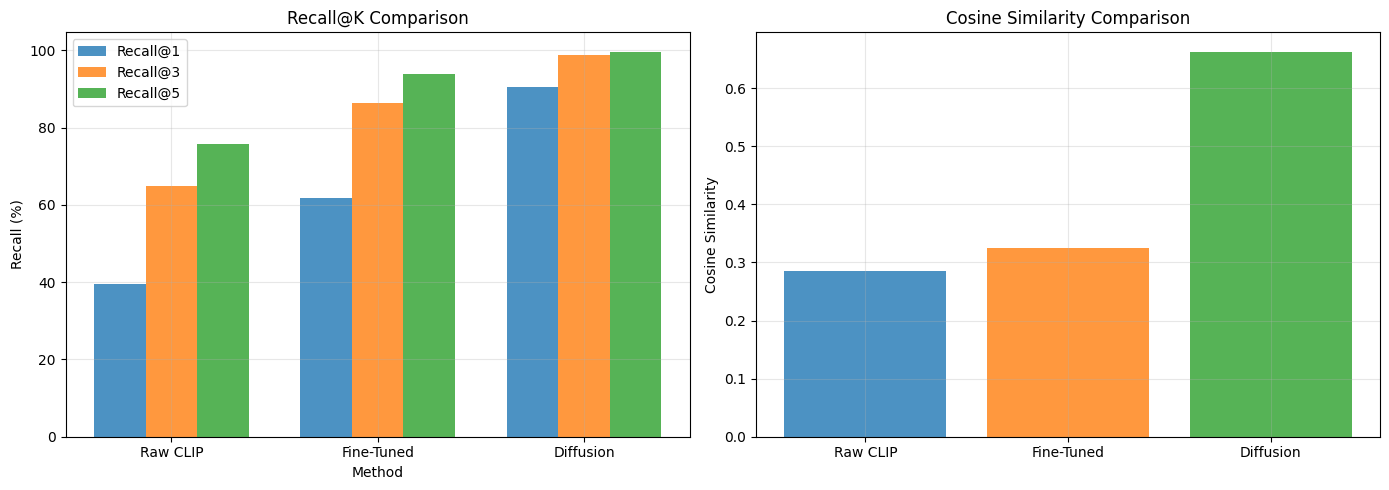

In [10]:
print("=" * 70)
print("PRELIMINARY EXPERIMENTS: Comparing All Methods")
print("=" * 70)

# Evaluate all methods on test set
print("\n1. Evaluating Raw CLIP (baseline)...")
raw_metrics = evaluate_method(test_loader, method="raw")

print("\n2. Evaluating Contrastive Fine-Tuned CLIP...")
baseline_metrics = evaluate_method(test_loader, method="baseline", model=baseline_model)

print("\n3. Evaluating Diffusion Denoising...")
diffusion_metrics = evaluate_method(test_loader, method="diffusion", denoiser=denoiser)

# Create comparison table
comparison_data = {
    "Method": ["Raw CLIP", "Contrastive Fine-Tuned", "Diffusion Denoised"],
    "Recall@1 (%)": [
        f"{raw_metrics['Recall@1']:.2f}",
        f"{baseline_metrics['Recall@1']:.2f}",
        f"{diffusion_metrics['Recall@1']:.2f}"
    ],
    "Recall@3 (%)": [
        f"{raw_metrics['Recall@3']:.2f}",
        f"{baseline_metrics['Recall@3']:.2f}",
        f"{diffusion_metrics['Recall@3']:.2f}"
    ],
    "Recall@5 (%)": [
        f"{raw_metrics['Recall@5']:.2f}",
        f"{baseline_metrics['Recall@5']:.2f}",
        f"{diffusion_metrics['Recall@5']:.2f}"
    ],
    "Cosine Similarity": [
        f"{raw_metrics['CosineMean']:.4f}",
        f"{baseline_metrics['CosineMean']:.4f}",
        f"{diffusion_metrics['CosineMean']:.4f}"
    ]
}

df = pd.DataFrame(comparison_data)
print("\n" + "=" * 70)
print("COMPARISON RESULTS")
print("=" * 70)
print(df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall@K comparison
methods = ["Raw CLIP", "Fine-Tuned", "Diffusion"]
recall1 = [raw_metrics['Recall@1'], baseline_metrics['Recall@1'], diffusion_metrics['Recall@1']]
recall3 = [raw_metrics['Recall@3'], baseline_metrics['Recall@3'], diffusion_metrics['Recall@3']]
recall5 = [raw_metrics['Recall@5'], baseline_metrics['Recall@5'], diffusion_metrics['Recall@5']]

x = np.arange(len(methods))
width = 0.25
axes[0].bar(x - width, recall1, width, label='Recall@1', alpha=0.8)
axes[0].bar(x, recall3, width, label='Recall@3', alpha=0.8)
axes[0].bar(x + width, recall5, width, label='Recall@5', alpha=0.8)
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Recall (%)')
axes[0].set_title('Recall@K Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cosine similarity comparison
cosine_vals = [raw_metrics['CosineMean'], baseline_metrics['CosineMean'], diffusion_metrics['CosineMean']]
axes[1].bar(methods, cosine_vals, alpha=0.8, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_title('Cosine Similarity Comparison')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 7: Hyperparameter Ablation Studies

In [11]:
print("=" * 80)
print("COMBINED HYPERPARAMETER ABLATION")
print("λ₁ / λ₂  | Noise Schedule | Max Noise")
print("=" * 80)

# -----------------------------
# Ablation search space
# -----------------------------
lambda_combinations = [
    (0.5, 0.5), (1.0, 1.0), (1.5, 1.5),
    (1.0, 0.5), (1.0, 1.5),
    (0.5, 1.0), (1.5, 1.0)
]

noise_schedules = ["linear", "cosine"]
max_noise_levels = [0.1, 0.2, 0.3, 0.4]

ablation_results = []

# -----------------------------
# Unified experiment loop
# -----------------------------
for λ1, λ2 in lambda_combinations:
    for schedule in noise_schedules:
        for max_noise in max_noise_levels:

            print(f"\nTesting λ₁={λ1}, λ₂={λ2}, "
                  f"schedule={schedule}, max_noise={max_noise}")

            # Fresh model for fair comparison
            denoiser = UNet1DResidualDenoiser(
                embedding_dim=512,
                hidden_dim=1024
            ).to(device)

            optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-4)

            # -----------------------------
            # Short training (ablation)
            # -----------------------------
            for epoch in range(5):
                denoiser.train()
                for images, captions in train_loader:
                    img_embeds, txt_embeds = get_clip_embeddings(images, captions)
                    t = torch.rand(1).item()

                    if schedule == "linear":
                        noisy_img = add_noise_linear(img_embeds, t, max_noise)
                        noisy_txt = add_noise_linear(txt_embeds, t, max_noise)
                    else:
                        noisy_img = add_noise_cosine(img_embeds, t, max_noise)
                        noisy_txt = add_noise_cosine(txt_embeds, t, max_noise)

                    denoised_img = denoiser(
                        noisy_img, x_clean=img_embeds, cond=txt_embeds
                    )
                    denoised_txt = denoiser(
                        noisy_txt, x_clean=txt_embeds, cond=img_embeds
                    )

                    mse_loss = (
                        λ1 * F.mse_loss(denoised_img, img_embeds) +
                        λ2 * F.mse_loss(denoised_txt, txt_embeds)
                    )

                    cont_loss = contrastive_loss(
                        denoised_img, denoised_txt, temperature=0.07
                    )

                    loss = mse_loss + cont_loss

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

            # -----------------------------
            # Evaluation
            # -----------------------------
            metrics = evaluate_method(
                test_loader,
                method="diffusion",
                denoiser=denoiser
            )

            ablation_results.append({
                "λ₁": λ1,
                "λ₂": λ2,
                "Schedule": schedule,
                "Max Noise": max_noise,
                "Recall@1": metrics["Recall@1"],
                "Recall@5": metrics["Recall@5"],
                "Cosine": metrics["CosineMean"]
            })

            print(f"  Recall@1: {metrics['Recall@1']:.2f}% | "
                  f"Cosine: {metrics['CosineMean']:.4f}")


COMBINED HYPERPARAMETER ABLATION
λ₁ / λ₂  | Noise Schedule | Max Noise

Testing λ₁=0.5, λ₂=0.5, schedule=linear, max_noise=0.1
  Recall@1: 85.10% | Cosine: 0.7251

Testing λ₁=0.5, λ₂=0.5, schedule=linear, max_noise=0.2
  Recall@1: 70.50% | Cosine: 0.6696

Testing λ₁=0.5, λ₂=0.5, schedule=linear, max_noise=0.3
  Recall@1: 77.30% | Cosine: 0.4465

Testing λ₁=0.5, λ₂=0.5, schedule=linear, max_noise=0.4
  Recall@1: 70.80% | Cosine: 0.3105

Testing λ₁=0.5, λ₂=0.5, schedule=cosine, max_noise=0.1
  Recall@1: 87.90% | Cosine: 0.7193

Testing λ₁=0.5, λ₂=0.5, schedule=cosine, max_noise=0.2
  Recall@1: 87.80% | Cosine: 0.6774

Testing λ₁=0.5, λ₂=0.5, schedule=cosine, max_noise=0.3
  Recall@1: 91.40% | Cosine: 0.6344

Testing λ₁=0.5, λ₂=0.5, schedule=cosine, max_noise=0.4
  Recall@1: 90.90% | Cosine: 0.6189

Testing λ₁=1.0, λ₂=1.0, schedule=linear, max_noise=0.1
  Recall@1: 73.30% | Cosine: 0.7218

Testing λ₁=1.0, λ₂=1.0, schedule=linear, max_noise=0.2
  Recall@1: 74.40% | Cosine: 0.6902

Testing 

In [12]:
ablation_df = pd.DataFrame(ablation_results)

print("\n" + "=" * 80)
print("FINAL ABLATION RESULTS")
print("=" * 80)
print(ablation_df.to_string(index=False))

best_idx = ablation_df["Recall@1"].idxmax()
best_cfg = ablation_df.loc[best_idx]

print("\nBEST CONFIGURATION:")
print(best_cfg)



FINAL ABLATION RESULTS
 λ₁  λ₂ Schedule  Max Noise  Recall@1  Recall@5   Cosine
0.5 0.5   linear        0.1      85.1      99.0 0.725067
0.5 0.5   linear        0.2      70.5      96.6 0.669620
0.5 0.5   linear        0.3      77.3      97.5 0.446502
0.5 0.5   linear        0.4      70.8      96.7 0.310502
0.5 0.5   cosine        0.1      87.9      99.4 0.719306
0.5 0.5   cosine        0.2      87.8      99.6 0.677351
0.5 0.5   cosine        0.3      91.4      99.6 0.634433
0.5 0.5   cosine        0.4      90.9      99.5 0.618864
1.0 1.0   linear        0.1      73.3      97.6 0.721801
1.0 1.0   linear        0.2      74.4      97.3 0.690249
1.0 1.0   linear        0.3      75.3      97.8 0.442683
1.0 1.0   linear        0.4      72.6      96.0 0.326657
1.0 1.0   cosine        0.1      86.3      98.7 0.714338
1.0 1.0   cosine        0.2      84.4      99.0 0.711914
1.0 1.0   cosine        0.3      84.5      99.4 0.671605
1.0 1.0   cosine        0.4      89.5      99.6 0.641034
1.5 1.5

## Step 8: Final Comparison Summary


In [13]:
print("=" * 70)
print("FINAL COMPARISON: All Methods on Test Set")
print("=" * 70)

# Final evaluation on test set
final_raw = evaluate_method(test_loader, method="raw")
final_baseline = evaluate_method(test_loader, method="baseline", model=baseline_model)
final_diffusion = evaluate_method(test_loader, method="diffusion", denoiser=denoiser)

# Create final comparison table
final_comparison = pd.DataFrame({
    "Method": ["Raw CLIP", "Contrastive Fine-Tuned", "Diffusion Denoised"],
    "Recall@1 (%)": [
        f"{final_raw['Recall@1']:.2f}",
        f"{final_baseline['Recall@1']:.2f}",
        f"{final_diffusion['Recall@1']:.2f}"
    ],
    "Recall@3 (%)": [
        f"{final_raw['Recall@3']:.2f}",
        f"{final_baseline['Recall@3']:.2f}",
        f"{final_diffusion['Recall@3']:.2f}"
    ],
    "Recall@5 (%)": [
        f"{final_raw['Recall@5']:.2f}",
        f"{final_baseline['Recall@5']:.2f}",
        f"{final_diffusion['Recall@5']:.2f}"
    ],
    "Cosine Similarity": [
        f"{final_raw['CosineMean']:.4f}",
        f"{final_baseline['CosineMean']:.4f}",
        f"{final_diffusion['CosineMean']:.4f}"
    ],
    "Improvement over Raw": [
        "-",
        f"+{final_baseline['Recall@1'] - final_raw['Recall@1']:.2f}%",
        f"+{final_diffusion['Recall@1'] - final_raw['Recall@1']:.2f}%"
    ]
})

print(final_comparison.to_string(index=False))

print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)
print(f"1. Raw CLIP Baseline:")
print(f"   Recall@1: {final_raw['Recall@1']:.2f}%, Cosine: {final_raw['CosineMean']:.4f}")
print(f"\n2. Contrastive Fine-Tuning:")
print(f"   Recall@1: {final_baseline['Recall@1']:.2f}% (+{final_baseline['Recall@1'] - final_raw['Recall@1']:.2f}%)")
print(f"   Cosine: {final_baseline['CosineMean']:.4f} (+{final_baseline['CosineMean'] - final_raw['CosineMean']:.4f})")
print(f"\n3. Diffusion Denoising:")
print(f"   Recall@1: {final_diffusion['Recall@1']:.2f}% (+{final_diffusion['Recall@1'] - final_raw['Recall@1']:.2f}%)")
print(f"   Cosine: {final_diffusion['CosineMean']:.4f} (+{final_diffusion['CosineMean'] - final_raw['CosineMean']:.4f})")
print("=" * 70)


FINAL COMPARISON: All Methods on Test Set
                Method Recall@1 (%) Recall@3 (%) Recall@5 (%) Cosine Similarity Improvement over Raw
              Raw CLIP        39.50        65.00        75.80            0.2856                    -
Contrastive Fine-Tuned        61.90        86.50        93.80            0.3245              +22.40%
    Diffusion Denoised        91.90        99.30        99.90            0.6292              +52.40%

KEY FINDINGS
1. Raw CLIP Baseline:
   Recall@1: 39.50%, Cosine: 0.2856

2. Contrastive Fine-Tuning:
   Recall@1: 61.90% (+22.40%)
   Cosine: 0.3245 (+0.0389)

3. Diffusion Denoising:
   Recall@1: 91.90% (+52.40%)
   Cosine: 0.6292 (+0.3436)


## Step 9: Embedding Visualization and Cluster Analysis

In [14]:
# Import libraries for visualization and clustering
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("=" * 70)
print("EMBEDDING VISUALIZATION AND CLUSTER ANALYSIS")
print("=" * 70)

# Collect embeddings from test set (use subset for faster computation)
print("\nCollecting embeddings from test set...")
all_img_embeds_raw = []
all_txt_embeds_raw = []
all_img_embeds_baseline = []
all_txt_embeds_baseline = []
all_img_embeds_diffusion = []
all_txt_embeds_diffusion = []

# Use subset for visualization (first 200 samples for speed)
sample_count = 0
max_samples = 200

baseline_model.eval()
denoiser.eval()

for images, captions in test_loader:
    if sample_count >= max_samples:
        break
    
    # Raw CLIP embeddings
    img_embeds, txt_embeds = get_clip_embeddings(images, captions)
    all_img_embeds_raw.append(img_embeds.cpu())
    all_txt_embeds_raw.append(txt_embeds.cpu())
    
    # Baseline (Fine-tuned) embeddings
    with torch.no_grad():
        inputs = processor(
            text=captions, images=images, return_tensors="pt",
            padding=True, truncation=True, max_length=77
        ).to(device)
        outputs = baseline_model(**inputs)
        baseline_img = F.normalize(outputs.image_embeds, dim=-1).cpu()
        baseline_txt = F.normalize(outputs.text_embeds, dim=-1).cpu()
    all_img_embeds_baseline.append(baseline_img)
    all_txt_embeds_baseline.append(baseline_txt)
    
    # Diffusion denoised embeddings
    with torch.no_grad():
        denoised_img = F.normalize(denoiser(img_embeds, cond=txt_embeds), dim=-1)
        denoised_txt = F.normalize(denoiser(txt_embeds, cond=img_embeds), dim=-1)
    all_img_embeds_diffusion.append(denoised_img.cpu())
    all_txt_embeds_diffusion.append(denoised_txt.cpu())
    
    sample_count += len(images)

# Concatenate all embeddings
img_embeds_raw = torch.cat(all_img_embeds_raw, dim=0).numpy()
txt_embeds_raw = torch.cat(all_txt_embeds_raw, dim=0).numpy()
img_embeds_baseline = torch.cat(all_img_embeds_baseline, dim=0).numpy()
txt_embeds_baseline = torch.cat(all_txt_embeds_baseline, dim=0).numpy()
img_embeds_diffusion = torch.cat(all_img_embeds_diffusion, dim=0).numpy()
txt_embeds_diffusion = torch.cat(all_txt_embeds_diffusion, dim=0).numpy()

print(f"Collected {len(img_embeds_raw)} sample pairs")
print(f"Embedding dimension: {img_embeds_raw.shape[1]}")

EMBEDDING VISUALIZATION AND CLUSTER ANALYSIS

Collected 224 sample pairs
Embedding dimension: 512



EMBEDDING SPACE VISUALIZATION (t-SNE)

Running t-SNE (this may take a minute)...


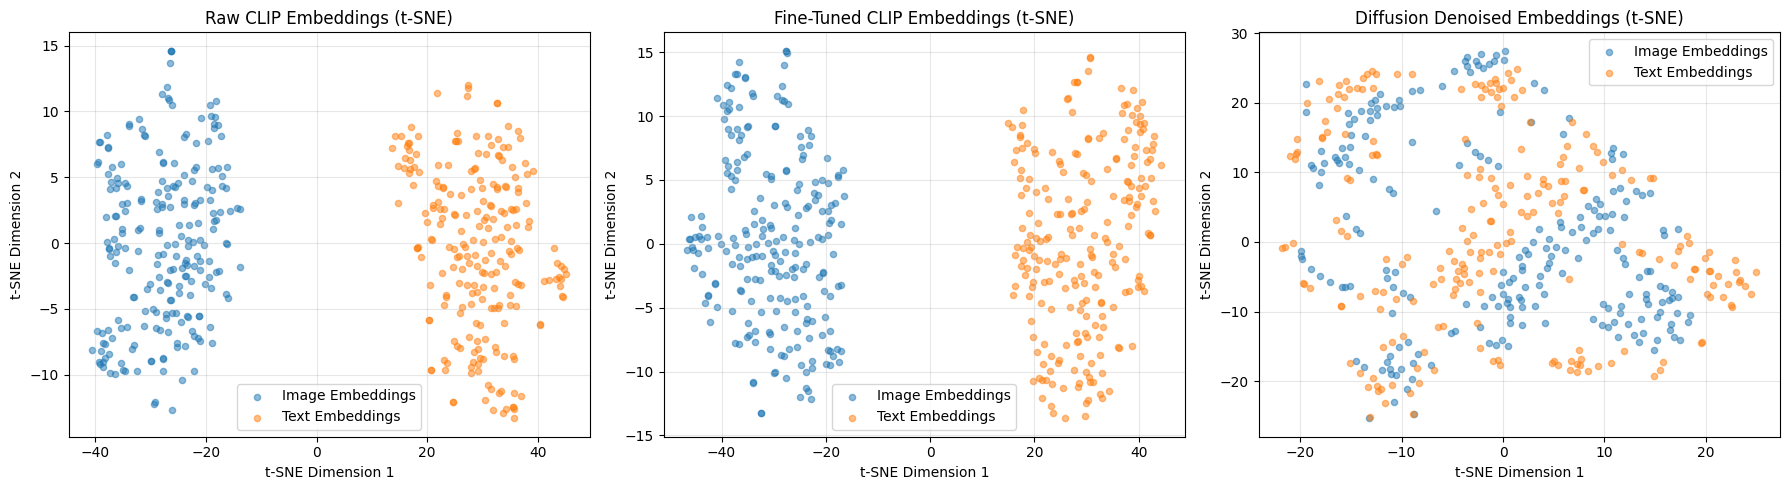


Visualization complete!
Observation: Compare alignment between image and text embeddings across all three methods


In [15]:
### 9.1: Embedding Space Visualization (t-SNE)

print("\n" + "=" * 70)
print("EMBEDDING SPACE VISUALIZATION (t-SNE)")
print("=" * 70)

# Combine image and text embeddings for visualization
combined_raw = np.vstack([img_embeds_raw, txt_embeds_raw])
combined_baseline = np.vstack([img_embeds_baseline, txt_embeds_baseline])
combined_diffusion = np.vstack([img_embeds_diffusion, txt_embeds_diffusion])

# Reduce to 2D using t-SNE
print("\nRunning t-SNE (this may take a minute)...")
tsne_raw = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_2d_raw = tsne_raw.fit_transform(combined_raw)

tsne_baseline = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_2d_baseline = tsne_baseline.fit_transform(combined_baseline)

tsne_diffusion = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_2d_diffusion = tsne_diffusion.fit_transform(combined_diffusion)

# Split back into image and text
n_samples = len(img_embeds_raw)
img_2d_raw = embeddings_2d_raw[:n_samples]
txt_2d_raw = embeddings_2d_raw[n_samples:]
img_2d_baseline = embeddings_2d_baseline[:n_samples]
txt_2d_baseline = embeddings_2d_baseline[n_samples:]
img_2d_diffusion = embeddings_2d_diffusion[:n_samples]
txt_2d_diffusion = embeddings_2d_diffusion[n_samples:]

# Plot visualization (3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw CLIP embeddings
axes[0].scatter(img_2d_raw[:, 0], img_2d_raw[:, 1], alpha=0.5, label='Image Embeddings', s=20)
axes[0].scatter(txt_2d_raw[:, 0], txt_2d_raw[:, 1], alpha=0.5, label='Text Embeddings', s=20)
axes[0].set_title('Raw CLIP Embeddings (t-SNE)', fontsize=12)
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Baseline (Fine-tuned) embeddings
axes[1].scatter(img_2d_baseline[:, 0], img_2d_baseline[:, 1], alpha=0.5, label='Image Embeddings', s=20)
axes[1].scatter(txt_2d_baseline[:, 0], txt_2d_baseline[:, 1], alpha=0.5, label='Text Embeddings', s=20)
axes[1].set_title('Fine-Tuned CLIP Embeddings (t-SNE)', fontsize=12)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Diffusion denoised embeddings
axes[2].scatter(img_2d_diffusion[:, 0], img_2d_diffusion[:, 1], alpha=0.5, label='Image Embeddings', s=20)
axes[2].scatter(txt_2d_diffusion[:, 0], txt_2d_diffusion[:, 1], alpha=0.5, label='Text Embeddings', s=20)
axes[2].set_title('Diffusion Denoised Embeddings (t-SNE)', fontsize=12)
axes[2].set_xlabel('t-SNE Dimension 1')
axes[2].set_ylabel('t-SNE Dimension 2')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")
print("Observation: Compare alignment between image and text embeddings across all three methods")


CLUSTER ANALYSIS

Performing K-means clustering with 10 clusters...

Silhouette Score (higher is better, range: -1 to 1):
  Raw CLIP: 0.0890
  Fine-Tuned CLIP: 0.0728
  Diffusion Denoised: 0.1060

Improvements:
  Fine-Tuned vs Raw: -0.0162
  Diffusion vs Raw: 0.0169
  Diffusion vs Fine-Tuned: 0.0332


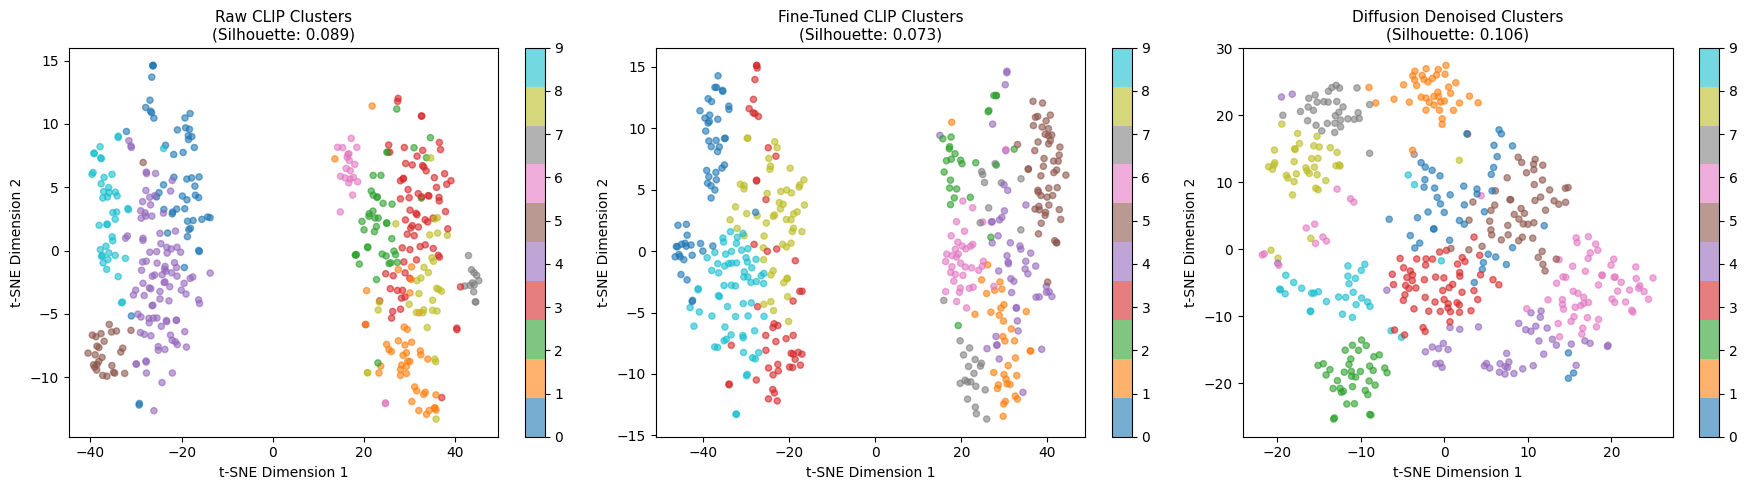


Cluster Analysis Complete!
Higher silhouette score indicates better-defined clusters (better semantic grouping)


In [16]:
### 9.2: Cluster Analysis

print("\n" + "=" * 70)
print("CLUSTER ANALYSIS")
print("=" * 70)

# K-means clustering on combined embeddings
n_clusters = 10  # Number of clusters
print(f"\nPerforming K-means clustering with {n_clusters} clusters...")

# Raw CLIP embeddings
kmeans_raw = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(combined_raw)
silhouette_raw = silhouette_score(combined_raw, labels_raw)

# Baseline (Fine-tuned) embeddings
kmeans_baseline = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_baseline = kmeans_baseline.fit_predict(combined_baseline)
silhouette_baseline = silhouette_score(combined_baseline, labels_baseline)

# Diffusion denoised embeddings
kmeans_diffusion = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_diffusion = kmeans_diffusion.fit_predict(combined_diffusion)
silhouette_diffusion = silhouette_score(combined_diffusion, labels_diffusion)

# Compare cluster quality
print(f"\nSilhouette Score (higher is better, range: -1 to 1):")
print(f"  Raw CLIP: {silhouette_raw:.4f}")
print(f"  Fine-Tuned CLIP: {silhouette_baseline:.4f}")
print(f"  Diffusion Denoised: {silhouette_diffusion:.4f}")
print(f"\nImprovements:")
print(f"  Fine-Tuned vs Raw: {silhouette_baseline - silhouette_raw:.4f}")
print(f"  Diffusion vs Raw: {silhouette_diffusion - silhouette_raw:.4f}")
print(f"  Diffusion vs Fine-Tuned: {silhouette_diffusion - silhouette_baseline:.4f}")

# Visualize clusters (3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw CLIP clusters
scatter1 = axes[0].scatter(embeddings_2d_raw[:, 0], embeddings_2d_raw[:, 1], 
                          c=labels_raw, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title(f'Raw CLIP Clusters\n(Silhouette: {silhouette_raw:.3f})', fontsize=11)
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
plt.colorbar(scatter1, ax=axes[0])

# Baseline (Fine-tuned) clusters
scatter2 = axes[1].scatter(embeddings_2d_baseline[:, 0], embeddings_2d_baseline[:, 1], 
                          c=labels_baseline, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title(f'Fine-Tuned CLIP Clusters\n(Silhouette: {silhouette_baseline:.3f})', fontsize=11)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
plt.colorbar(scatter2, ax=axes[1])

# Diffusion denoised clusters
scatter3 = axes[2].scatter(embeddings_2d_diffusion[:, 0], embeddings_2d_diffusion[:, 1], 
                          c=labels_diffusion, cmap='tab10', alpha=0.6, s=20)
axes[2].set_title(f'Diffusion Denoised Clusters\n(Silhouette: {silhouette_diffusion:.3f})', fontsize=11)
axes[2].set_xlabel('t-SNE Dimension 1')
axes[2].set_ylabel('t-SNE Dimension 2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

print("\nCluster Analysis Complete!")
print("Higher silhouette score indicates better-defined clusters (better semantic grouping)")